In [7]:
import matplotlib.pyplot as plt
import pandas as pd

## Lifecycle Stages Bar Chart

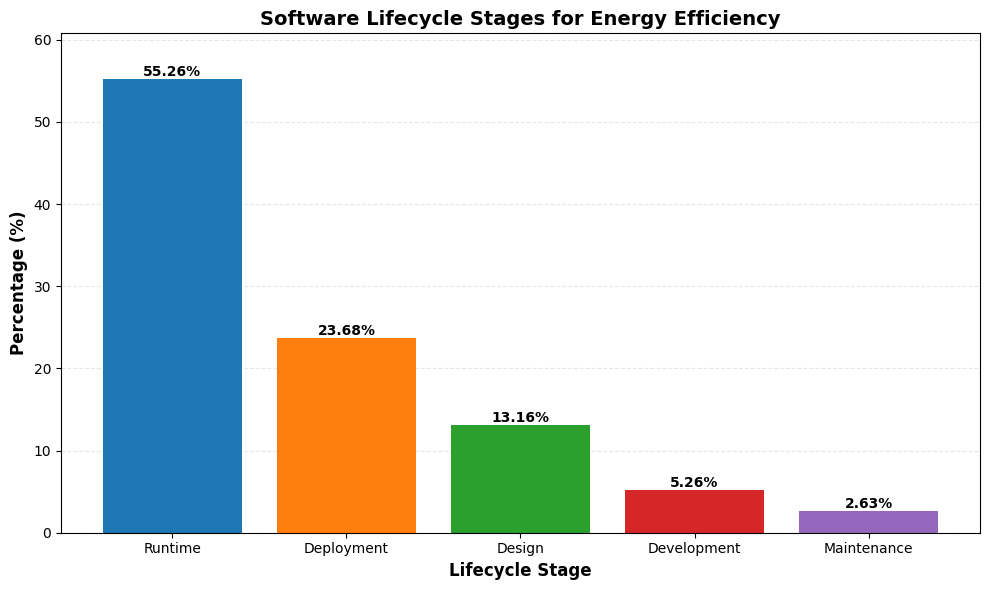

In [8]:
# Create the data
data = {
    'LifecycleStage': ['Runtime', 'Deployment', 'Design', 'Development', 'Maintenance'],
    'Count': [21, 9, 5, 2, 1],
    'Percentage': [55.26, 23.68, 13.16, 5.26, 2.63]
}

df = pd.DataFrame(data)

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['LifecycleStage'], df['Percentage'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize the chart
ax.set_xlabel('Lifecycle Stage', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Software Lifecycle Stages for Energy Efficiency', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(df['Percentage']) * 1.1)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## RQ1.1
```values
RQ1.1.P1	LifecycleStage	Represents the stages of the software lifecycle where energy efficiency is considered.	Runtime	21	55.26%
			Deployment	9	23.68%
			Design	5	13.16%
			Development	2	5.26%
			Maintenance	1	2.63%
			Total	38	
RQ1.1.P2	EnergyAwarenessStage	Describes how energy efficiency is addressed at each stage: eplicitly, implicitly, or post deployment	Runtime	19	65.52%
			Design	4	13.79%
			Deployment	3	10.34%
			Analysis	1	3.45%
			Configuration	1	3.45%
			Development	1	3.45%
			Total	29	
RQ1.1.P3	IntegrationApproach	Indicates the method used to integrate energy effieiency considerations into the system	RuntimeMonitoring	18	34.62%
			RuntimeAdaptation	8	15.38%
			RuntimeScheduling	6	11.54%
			RuntimePowerManagement	5	9.62%
			RuntimeDeploymentManagement	4	7.69%
			QoSDrivenControl	3	5.77%
			MetadataDrivenIntegration	2	3.85%
			RuntimeAutoscaling	2	3.85%
			Brownout	1	1.92%
			DesignTimeAnalysis	1	1.92%
			DesignTimeConstraints	1	1.92%
			PlacementOptimization	1	1.92%
			Total	52	
```

## Sankey Diagram - RQ1.1

In [9]:
import plotly.graph_objects as go

# Define nodes
nodes = [
    # LifecycleStage nodes (0-4)
    "Runtime", "Deployment", "Design", "Development", "Maintenance",
    # EnergyAwarenessStage nodes (5-10)
    "Runtime (EA)", "Design (EA)", "Deployment (EA)", "Analysis", "Configuration", "Development (EA)",
    # IntegrationApproach nodes (11-22)
    "RuntimeMonitoring", "RuntimeAdaptation", "RuntimeScheduling", "RuntimePowerManagement",
    "RuntimeDeploymentManagement", "QoSDrivenControl", "MetadataDrivenIntegration",
    "RuntimeAutoscaling", "Brownout", "DesignTimeAnalysis", "DesignTimeConstraints",
    "PlacementOptimization"
]

# Define links (source, target, value)
# LifecycleStage -> EnergyAwarenessStage
# Runtime (0) flows to Runtime (EA) (5)
# Design (2) flows to Design (EA) (6)
# Deployment (1) flows to Deployment (EA) (7)
# Development (3) flows to Development (EA) (10)

links = [
    # LifecycleStage to EnergyAwarenessStage
    (0, 5, 19),  # Runtime -> Runtime (EA)
    (2, 6, 4),   # Design -> Design (EA)
    (1, 7, 3),   # Deployment -> Deployment (EA)
    (3, 10, 1),  # Development -> Development (EA)
    
    # EnergyAwarenessStage to IntegrationApproach
    # Runtime (EA) to runtime approaches
    (5, 11, 18),  # Runtime (EA) -> RuntimeMonitoring
    (5, 12, 8),   # Runtime (EA) -> RuntimeAdaptation
    (5, 13, 6),   # Runtime (EA) -> RuntimeScheduling
    (5, 14, 5),   # Runtime (EA) -> RuntimePowerManagement
    (5, 15, 4),   # Runtime (EA) -> RuntimeDeploymentManagement
    (5, 16, 3),   # Runtime (EA) -> QoSDrivenControl
    (5, 17, 2),   # Runtime (EA) -> MetadataDrivenIntegration
    (5, 18, 2),   # Runtime (EA) -> RuntimeAutoscaling
    (5, 19, 1),   # Runtime (EA) -> Brownout
    
    # Design (EA) to design-time approaches
    (6, 20, 1),   # Design (EA) -> DesignTimeAnalysis
    (6, 21, 1),   # Design (EA) -> DesignTimeConstraints
    
    # Deployment (EA) to deployment approaches
    (7, 22, 1),   # Deployment (EA) -> PlacementOptimization
]

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes,
        color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",  # LifecycleStage
               "#aec7e8", "#c7e9c0", "#ffbb78", "#98df8a", "#c5b0d5", "#bcbd22",  # EnergyAwarenessStage
               "#17becf", "#9edae5", "#dbdb8d", "#c49c94", "#f7b6d2", "#c7c7c7",  # IntegrationApproach
               "#bcbd22", "#e377c2", "#7f7f7f", "#8c564b", "#ff9896", "#17becf"]
    ),
    link=dict(
        source=[link[0] for link in links],
        target=[link[1] for link in links],
        value=[link[2] for link in links]
    )
)])

fig.update_layout(
    title="Energy Efficiency Integration: Lifecycle Stages to Integration Approaches",
    font_size=12,
    height=800,
    width=1200
)

fig.show()

## Sankey Diagram - RQ1.1 (Version 2 - Runtime Focus)

In [20]:
import plotly.graph_objects as go

# Define nodes - Runtime approaches first, then Design-time approaches
nodes = [
    # Source node
    "Runtime",
    # Runtime Integration Approaches (1-9)
    "RuntimeMonitoring", "RuntimeAdaptation", "RuntimeScheduling", "RuntimePowerManagement",
    "RuntimeDeploymentManagement", "QoSDrivenControl", "MetadataDrivenIntegration",
    "RuntimeAutoscaling", "Brownout",
    # Design-time Integration Approaches (10-12)
    "DesignTimeAnalysis", "DesignTimeConstraints", "PlacementOptimization"
]

# Define links with color coding
runtime_links = [
    (0, 1, 18),   # Runtime -> RuntimeMonitoring
    (0, 2, 8),    # Runtime -> RuntimeAdaptation
    (0, 3, 6),    # Runtime -> RuntimeScheduling
    (0, 4, 5),    # Runtime -> RuntimePowerManagement
    (0, 5, 4),    # Runtime -> RuntimeDeploymentManagement
    (0, 6, 3),    # Runtime -> QoSDrivenControl
    (0, 7, 2),    # Runtime -> MetadataDrivenIntegration
    (0, 8, 2),    # Runtime -> RuntimeAutoscaling
    (0, 9, 1),    # Runtime -> Brownout
]

designtime_links = [
    (0, 10, 1),   # Runtime -> DesignTimeAnalysis
    (0, 11, 1),   # Runtime -> DesignTimeConstraints
    (0, 12, 1),   # Runtime -> PlacementOptimization
]

# Combine all links
all_links = runtime_links + designtime_links

# Create link colors - blue for runtime, orange for design-time
link_colors = ["rgba(31, 119, 180, 0.4)"] * len(runtime_links) + \
              ["rgba(255, 127, 14, 0.4)"] * len(designtime_links)

# Node colors - blue for source, blue shades for runtime approaches, orange shades for design-time
node_colors = ["#1f77b4"] + \
              ["#4292c6", "#6baed6", "#9ecae1", "#c6dbef", "#deebf7", 
               "#3182bd", "#6baed6", "#9ecae1", "#c6dbef"] + \
              ["#ff7f0e", "#ffbb78", "#fdd0a2"]

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=25,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes,
        color=node_colors,
        align="right",

    ),
    link=dict(
        source=[link[0] for link in all_links],
        target=[link[1] for link in all_links],
        value=[link[2] for link in all_links],
        color=link_colors,
    )
)])

fig.update_layout(
    font_size=18,
    height=700,
    width=1000,
    margin=dict(l=50, r=200, t=40, b=10)
)

fig.show()

In [13]:
# Export the Sankey diagram as SVG and PDF
# Note: This requires the kaleido package. Install with: pip install kaleido

try:
    # Export as SVG (best for LaTeX - scalable and editable)
    svg_path = 'rq1.1_sankey_diagram.svg'
    fig.write_image(svg_path, format='svg')
    print(f"✓ SVG exported to: {svg_path}")
    
    # Export as PDF (also good for LaTeX)
    pdf_path = 'rq1.1_sankey_diagram.pdf'
    fig.write_image(pdf_path, format='pdf')
    print(f"✓ PDF exported to: {pdf_path}")
    
    print("\nFor LaTeX, use:")
    print("\\usepackage{graphicx}")
    print(f"\\includegraphics[width=\\textwidth]{{{svg_path}}} % or {pdf_path}")
    
except Exception as e:
    print(f"Error exporting: {e}")
    print("\nTo export, install kaleido:")
    print("pip install kaleido")

✓ SVG exported to: rq1.1_sankey_diagram.svg
✓ PDF exported to: rq1.1_sankey_diagram.pdf

For LaTeX, use:
\usepackage{graphicx}
\includegraphics[width=\textwidth]{rq1.1_sankey_diagram.svg} % or rq1.1_sankey_diagram.pdf


## Pie Charts - RQ1.1 Analysis

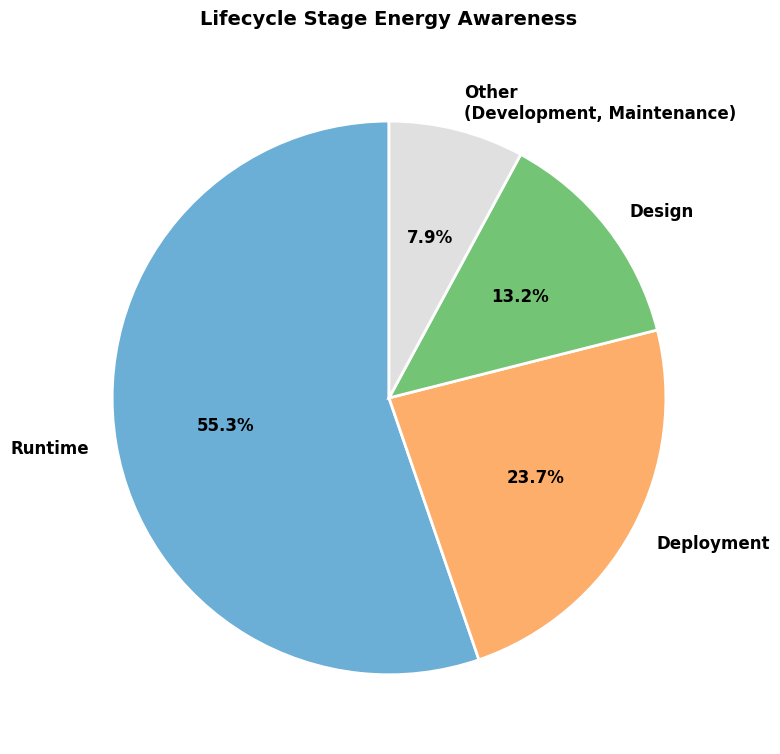

Chart 1 saved to: output/chart1_lifecycle_stage.png and .pdf


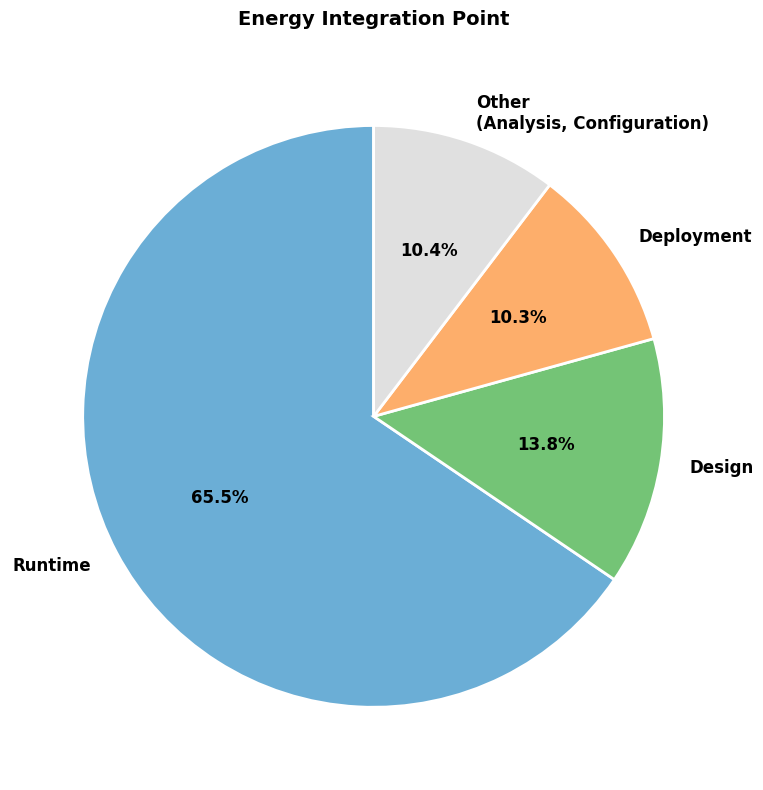

Chart 2 saved to: output/chart2_energy_integration.png and .pdf


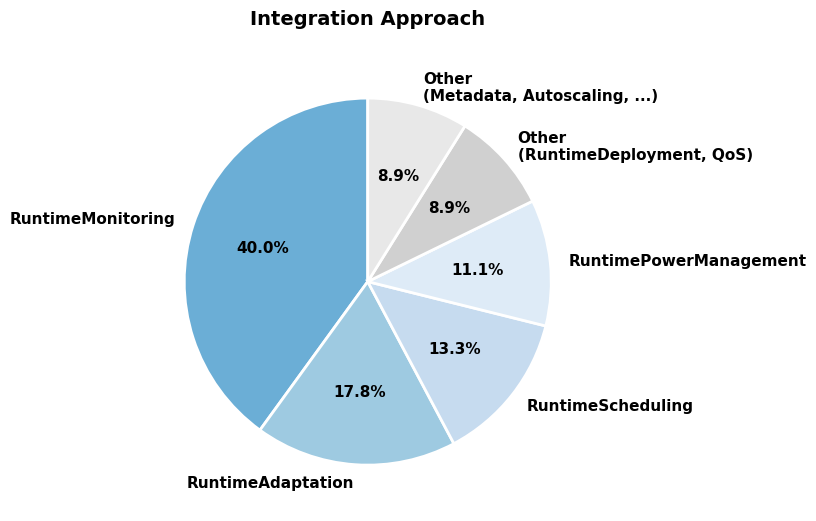

Chart 3 saved to: output/chart3_integration_approach.png and .pdf

=== Other Categories Breakdown ===

Chart 1 - Lifecycle Stage Energy Awareness (Other):
  • Development: 2 (5.26%)
  • Maintenance: 1 (2.63%)
  Total: 3 (7.89%)

Chart 2 - Energy Integration Point (Other):
  • Analysis: 1 (3.45%)
  • Configuration: 1 (3.45%)
  • Development: 1 (3.45%)
  Total: 3 (10.35%)

Chart 3 - Integration Approach (Other - RuntimeDeployment, QoS):
  • RuntimeDeploymentManagement: 2 (3.85%)
  • QoSDrivenControl: 2 (3.85%)
  Total: 4 (7.69%)

Chart 3 - Integration Approach (Other - Metadata, Autoscaling, ...):
  • MetadataDrivenIntegration: 1 (1.92%)
  • RuntimeAutoscaling: 1 (1.92%)
  • Brownout: 1 (1.92%)
  • DesignTimeAnalysis: 1 (1.92%)
  Total: 4 (7.69%)


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create output directory if it doesn't exist
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# Chart 1: Lifecycle Stage Energy Awareness
data1 = {
    'Category': ['Runtime', 'Deployment', 'Design', 'Other\n(Development, Maintenance)'],
    'Count': [21, 9, 5, 3],  # Development (2) + Maintenance (1) = Other (3)
    'Percentage': [55.26, 23.68, 13.16, 7.89]
}
df1 = pd.DataFrame(data1)
colors1 = ['#6baed6', '#fdae6b', '#74c476', '#e0e0e0']  # Lighter colors

fig1, ax1 = plt.subplots(figsize=(8, 8))
wedges1, texts1, autotexts1 = ax1.pie(
    df1['Percentage'], 
    labels=df1['Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax1.set_title('Lifecycle Stage Energy Awareness', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
fig1.savefig(os.path.join(output_dir, 'chart1_lifecycle_stage.png'), dpi=300, bbox_inches='tight')
fig1.savefig(os.path.join(output_dir, 'chart1_lifecycle_stage.pdf'), bbox_inches='tight')
plt.show()
print(f"Chart 1 saved to: {output_dir}/chart1_lifecycle_stage.png and .pdf")

# Chart 2: Energy Integration Point
data2 = {
    'Category': ['Runtime', 'Design', 'Deployment', 'Other\n(Analysis, Configuration)'],
    'Count': [19, 4, 3, 3],  # Analysis (1) + Configuration (1) + Development (1) = Other (3)
    'Percentage': [65.52, 13.79, 10.34, 10.35]
}
df2 = pd.DataFrame(data2)
colors2 = ['#6baed6', '#74c476', '#fdae6b', '#e0e0e0']  # Lighter colors

fig2, ax2 = plt.subplots(figsize=(8, 8))
wedges2, texts2, autotexts2 = ax2.pie(
    df2['Percentage'],
    labels=df2['Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Energy Integration Point', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
fig2.savefig(os.path.join(output_dir, 'chart2_energy_integration.png'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(output_dir, 'chart2_energy_integration.pdf'), bbox_inches='tight')
plt.show()
print(f"Chart 2 saved to: {output_dir}/chart2_energy_integration.png and .pdf")

# Chart 3: Integration Approach
# Separate items with count = 2 and count = 1
data3 = {
    'Category': ['RuntimeMonitoring', 'RuntimeAdaptation', 'RuntimeScheduling', 
                 'RuntimePowerManagement', 'Other\n(RuntimeDeployment, QoS)', 'Other\n(Metadata, Autoscaling, ...)'],
    'Count': [18, 8, 6, 5, 4, 4],  # 2 items with count=2 (4 total), 4 items with count=1 (4 total)
    'Percentage': [34.62, 15.38, 11.54, 9.62, 7.69, 7.69]
}
df3 = pd.DataFrame(data3)
colors3 = ['#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#d0d0d0', '#e8e8e8']  # Lighter shades of blue + grays

fig3, ax3 = plt.subplots(figsize=(8, 8))
wedges3, texts3, autotexts3 = ax3.pie(
    df3['Percentage'],
    labels=df3['Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors3,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax3.set_title('Integration Approach', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
fig3.savefig(os.path.join(output_dir, 'chart3_integration_approach.png'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(output_dir, 'chart3_integration_approach.pdf'), bbox_inches='tight')
plt.show()
print(f"Chart 3 saved to: {output_dir}/chart3_integration_approach.png and .pdf")

# Print breakdown of "Other" categories
print("\n=== Other Categories Breakdown ===\n")
print("Chart 1 - Lifecycle Stage Energy Awareness (Other):")
print("  • Development: 2 (5.26%)")
print("  • Maintenance: 1 (2.63%)")
print("  Total: 3 (7.89%)\n")

print("Chart 2 - Energy Integration Point (Other):")
print("  • Analysis: 1 (3.45%)")
print("  • Configuration: 1 (3.45%)")
print("  • Development: 1 (3.45%)")
print("  Total: 3 (10.35%)\n")

print("Chart 3 - Integration Approach (Other - RuntimeDeployment, QoS):")
print("  • RuntimeDeploymentManagement: 2 (3.85%)")
print("  • QoSDrivenControl: 2 (3.85%)")
print("  Total: 4 (7.69%)\n")

print("Chart 3 - Integration Approach (Other - Metadata, Autoscaling, ...):")
print("  • MetadataDrivenIntegration: 1 (1.92%)")
print("  • RuntimeAutoscaling: 1 (1.92%)")
print("  • Brownout: 1 (1.92%)")
print("  • DesignTimeAnalysis: 1 (1.92%)")
print("  Total: 4 (7.69%)")